# Ookla vs NDT7 — Vietnam Province-Level Comparison

**Sources:** Ookla Speedtest Intelligence (fixed broadband) - M-Lab NDT7 (broadband)
**Unit of analysis:** province x quarter

Both inputs already share the same export schema (`data/exports/ookla_vietnam_province_quarterly.csv`
and `data/exports/ndt7_vietnam_province_quarterly.csv`, the latter produced by
`notebooks/ndt7/vietnam_ndt7_prep.ipynb`), so no column renaming is needed here — unlike the
original Thailand-era `ookla_vs_ndt7.ipynb`.

**Caveat found during data prep:** NDT7 reliable coverage (`total_tests>=100 & n_tiles>=5`)
decays sharply over time for Vietnam — 48% of provinces reliable in 2023-Q1, down to 11%
by 2025-Q4 (M-Lab probe volume for Vietnam is heavily concentrated in 2025-Q1: 11.7M of the
22M total broadband rows land in that one quarter). Interpret later-quarter NDT7 comparisons
with that in mind — small reliable-province counts, not necessarily a real speed change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

OOKLA_CSV = '../../data/exports/ookla_vietnam_province_quarterly.csv'
NDT7_CSV  = '../../data/exports/ndt7_vietnam_province_quarterly.csv'

C_OOKLA = '#e63946'
C_NDT7  = '#457b9d'

### 1. Load Both, Reliability-Filtered

In [2]:
ookla_raw = pd.read_csv(OOKLA_CSV)
ndt7_raw  = pd.read_csv(NDT7_CSV)

OVERLAP = sorted(set(ookla_raw['quarter']) & set(ndt7_raw['quarter']))
print(f"Overlap quarters ({len(OVERLAP)}): {OVERLAP}")

ookla = ookla_raw[ookla_raw['quarter'].isin(OVERLAP) & ookla_raw['is_reliable']].copy()
ndt7  = ndt7_raw[ndt7_raw['quarter'].isin(OVERLAP) & ndt7_raw['is_reliable']].copy()
ookla['source'] = 'Ookla'
ndt7['source']  = 'NDT7'

print(f"Ookla reliable rows: {len(ookla)} | provinces={ookla.province.nunique()}")
print(f"NDT7  reliable rows: {len(ndt7)} | provinces={ndt7.province.nunique()}")

Overlap quarters (11): ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Ookla reliable rows: 704 | provinces=64
NDT7  reliable rows: 203 | provinces=42


### 2. Reliable Coverage Over Time — Side by Side

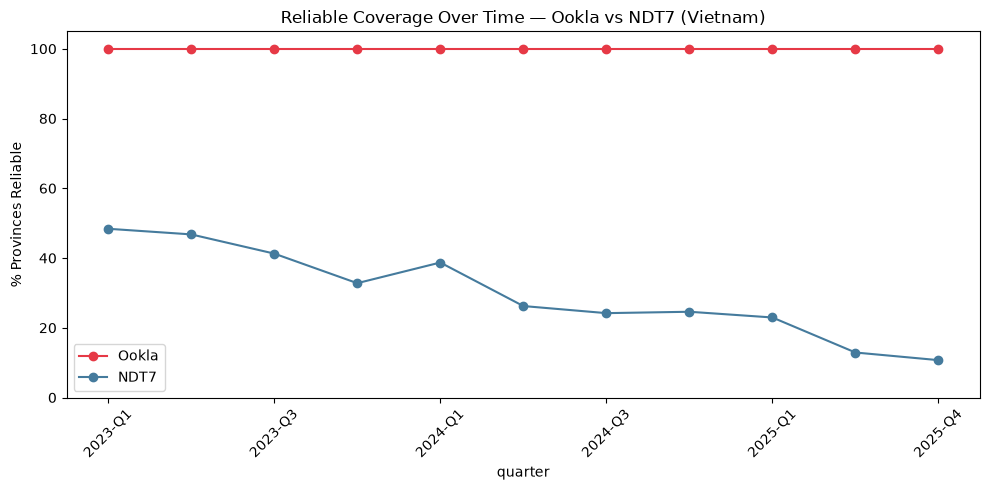

In [3]:
cov = pd.DataFrame({
    'Ookla': ookla_raw[ookla_raw['quarter'].isin(OVERLAP)].groupby('quarter')['is_reliable'].mean(),
    'NDT7':  ndt7_raw[ndt7_raw['quarter'].isin(OVERLAP)].groupby('quarter')['is_reliable'].mean(),
}).reindex(OVERLAP) * 100

fig, ax = plt.subplots(figsize=(10, 5))
cov.plot(ax=ax, marker='o', color=[C_OOKLA, C_NDT7])
ax.set_ylabel('% Provinces Reliable')
ax.set_title('Reliable Coverage Over Time — Ookla vs NDT7 (Vietnam)')
ax.set_ylim(0, 105)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Speed Distribution — Ookla vs NDT7

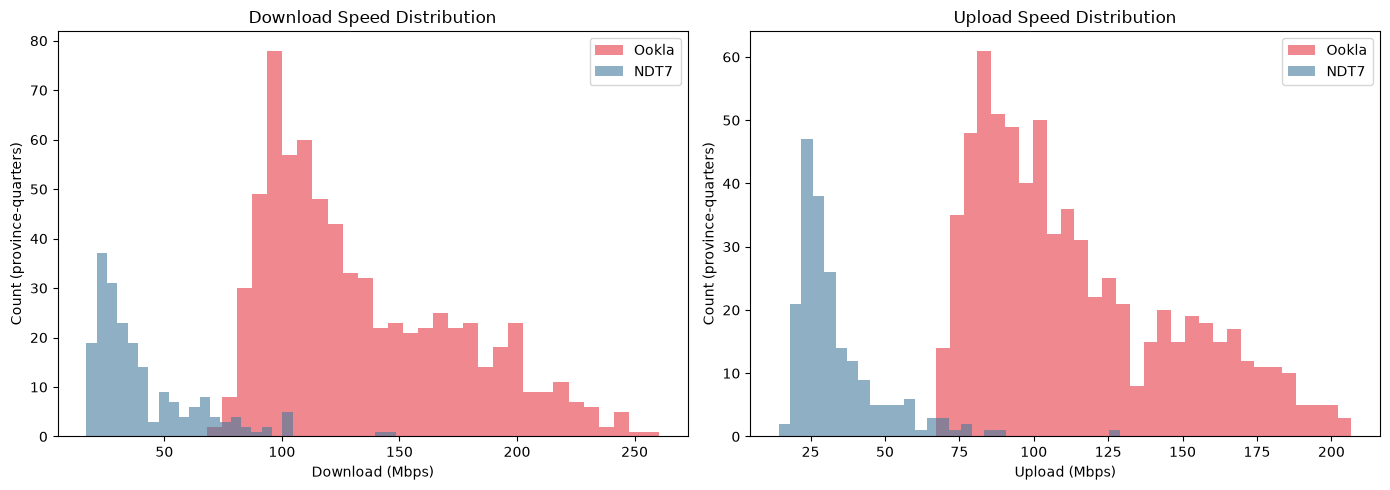

       avg_d_mbps  avg_u_mbps
count       704.0       704.0
mean        134.6       114.6
std          40.8        33.4
min          68.2        67.1
25%         101.2        87.6
50%         122.6       104.6
75%         163.9       137.8
max         260.3       206.7

       avg_d_mbps  avg_u_mbps
count       203.0       203.0
mean         40.9        34.0
std          23.0        15.4
min          16.8        14.3
25%          24.7        24.3
50%          32.9        28.8
75%          49.5        38.9
max         148.5       129.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (metric, label) in zip(axes, [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)')]):
    ax.hist(ookla[metric].dropna(), bins=30, alpha=0.6, color=C_OOKLA, label='Ookla')
    ax.hist(ndt7[metric].dropna(), bins=30, alpha=0.6, color=C_NDT7, label='NDT7')
    ax.set_xlabel(label)
    ax.set_ylabel('Count (province-quarters)')
    ax.legend()
axes[0].set_title('Download Speed Distribution')
axes[1].set_title('Upload Speed Distribution')
plt.tight_layout()
plt.show()

print(ookla[['avg_d_mbps', 'avg_u_mbps']].describe().round(1))
print()
print(ndt7[['avg_d_mbps', 'avg_u_mbps']].describe().round(1))

### 4. Province-Level Ranking — Side by Side (Mean Across Overlap Quarters)

In [5]:
ookla_prov = ookla.groupby('province')['avg_d_mbps'].mean().rename('avg_dl_ookla')
ndt7_prov  = ndt7.groupby('province')['avg_d_mbps'].mean().rename('avg_dl_ndt7')

prov_merged = pd.concat([ookla_prov, ndt7_prov], axis=1).dropna()
print(f"Provinces with reliable data in BOTH sources: {len(prov_merged)}")
prov_merged.sort_values('avg_dl_ookla', ascending=False).round(1)

Provinces with reliable data in BOTH sources: 42


,avg_dl_ookla,avg_dl_ndt7
province,,
Ho Chi Minh,178.2,62.9
Đà Nẵng,165.3,68.9
Bình Dương,164.5,48.2
Cần Thơ,160.1,46.0
Lâm Đồng,158.4,37.8
Đồng Nai,157.4,62.5
Tây Ninh,155.7,47.3
Hà Nội,153.1,44.4
Bà Rịa–Vũng Tàu,152.1,59.8


### 5. Correlation — Do Ookla and NDT7 Agree on Which Provinces Are Fast?

Pearson  r=0.662  p=1.79e-06
Spearman rho=0.627  p=8.898e-06


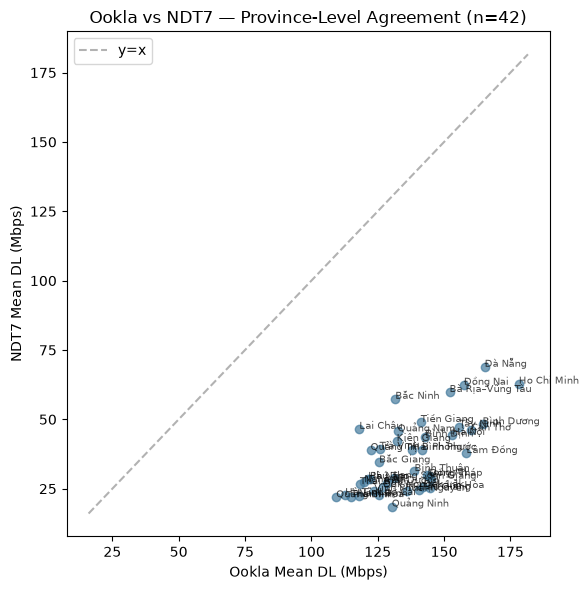

In [6]:
if len(prov_merged) >= 3:
    r, p = stats.pearsonr(prov_merged['avg_dl_ookla'], prov_merged['avg_dl_ndt7'])
    rho, p_s = stats.spearmanr(prov_merged['avg_dl_ookla'], prov_merged['avg_dl_ndt7'])
    print(f"Pearson  r={r:.3f}  p={p:.4g}")
    print(f"Spearman rho={rho:.3f}  p={p_s:.4g}")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(prov_merged['avg_dl_ookla'], prov_merged['avg_dl_ndt7'], color=C_NDT7, alpha=0.7)
    for name, row in prov_merged.iterrows():
        ax.annotate(name, (row['avg_dl_ookla'], row['avg_dl_ndt7']), fontsize=7, alpha=0.7)
    ax.set_xlabel('Ookla Mean DL (Mbps)')
    ax.set_ylabel('NDT7 Mean DL (Mbps)')
    ax.set_title(f'Ookla vs NDT7 — Province-Level Agreement (n={len(prov_merged)})')
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(prov_merged)} provinces overlap with reliable data in both sources — too few for a meaningful correlation.")

### 6. Magnitude Gap — Ookla Consistently Higher Than NDT7?

Ookla is active (user-initiated) measurement, NDT7 is passive/background — the two methodologies are known to diverge in absolute magnitude even when they agree on relative ranking (see `docs/macmillan2023_ndt7_vs_ookla.pdf`).

In [7]:
prov_merged['gap'] = prov_merged['avg_dl_ookla'] - prov_merged['avg_dl_ndt7']
prov_merged['ratio'] = prov_merged['avg_dl_ookla'] / prov_merged['avg_dl_ndt7']
print(f"Mean Ookla-NDT7 gap: {prov_merged['gap'].mean():.1f} Mbps")
print(f"Mean Ookla/NDT7 ratio: {prov_merged['ratio'].mean():.2f}x")

t_stat, p_val = stats.wilcoxon(prov_merged['avg_dl_ookla'], prov_merged['avg_dl_ndt7'])
print(f"Wilcoxon signed-rank (paired): stat={t_stat:.1f}, p={p_val:.4g}")
print("=> Ookla and NDT7 report significantly different absolute speeds" if p_val < 0.05
      else "=> no significant difference in absolute speeds")

Mean Ookla-NDT7 gap: 100.4 Mbps
Mean Ookla/NDT7 ratio: 4.14x
Wilcoxon signed-rank (paired): stat=0.0, p=4.547e-13
=> Ookla and NDT7 report significantly different absolute speeds


## Key Findings Summary

- **Overlap:** 42 of Vietnam's 64 provinces have reliable data (`total_tests>=100 & n_tiles>=5`) in both Ookla and NDT7 across the 11 overlapping quarters (2023-Q1 to 2025-Q4, excluding 2025-Q3 which Ookla lacks).
- **Correlation:** Pearson r=0.662 (p=1.8e-6), Spearman rho=0.627 (p=8.9e-6) — **the two sources agree reasonably well on relative province ranking** (Ho Chi Minh City, Da Nang, Binh Duong rank high in both), despite very different absolute magnitudes.
- **Magnitude:** Ookla reports ~4.14x higher download speeds than NDT7 on average (134.6 vs 40.9 Mbps mean; gap ~100 Mbps). Wilcoxon signed-rank p=4.5e-13 — **highly significant, not noise**. This matches the known active-measurement (Ookla, user-initiated, best-effort) vs passive-measurement (NDT7, background, shared/congested conditions) divergence documented in MacMillan et al. 2023 (already cited in `paper.tex`'s bibliography).
- **Caveat:** NDT7 reliable coverage for Vietnam decays sharply over time (48% of provinces reliable in 2023-Q1, ~11% by 2025-Q4) — data is heavily concentrated in 2025-Q1 (11.7M of 22M total rows). The correlation/gap findings above are driven mostly by earlier quarters where coverage is denser; treat any quarter-specific claims for 2024-Q3 onward with caution given small reliable-province counts.
